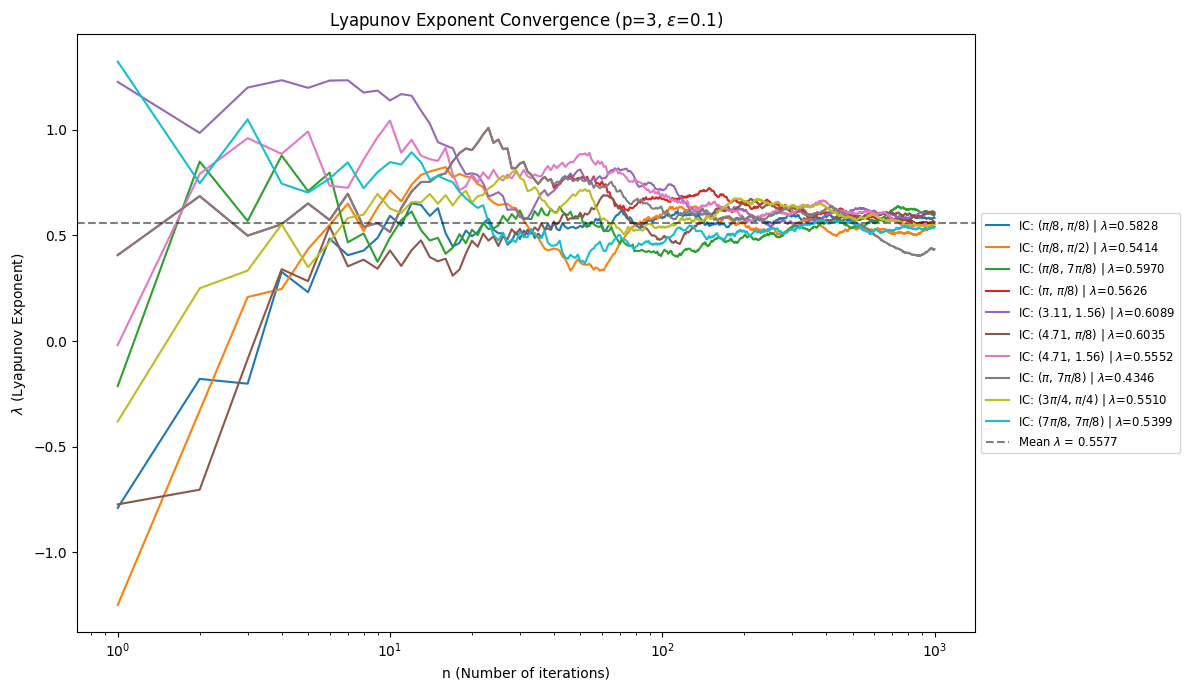

In [1]:
# from tqdm.notebook import tqdm
from concurrent.futures import as_completed
import matplotlib.pyplot as plt
# from matplotlib.ticker import LogLocator
import numpy as np
from billiard_engine import run_convergence_task, BilliardsNonTimeDependent
from concurrent.futures import ProcessPoolExecutor
from telemetry import Monitor
import time
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator


def format_coord(val):
    """Helper to convert float multiples of pi to LaTeX strings."""
    # Calculate the multiple of pi
    multiple = val / np.pi
    
    if np.isclose(multiple, 0.125): return r"$\pi/8$"
    if np.isclose(multiple, 0.25):  return r"$\pi/4$"
    if np.isclose(multiple, 0.5):   return r"$\pi/2$"
    if np.isclose(multiple, 0.75):  return r"$3\pi/4$"
    if np.isclose(multiple, 0.75):  return r"$3\pi/4$"
    if np.isclose(multiple, 0.875): return r"$7\pi/8$"
    if np.isclose(multiple, 1.0):   return r"$\pi$"
    
    # Fallback to 2 decimal places if it doesn't match a common fraction
    return f"{val:.2f}"

if __name__ == "__main__":
    data = np.load("billiard_results.npz")
    m, epsilon, n_iters = data['metadata']
    seeds = data['seeds']

    plt.figure(figsize=(12, 7))

    final_lambdas = []

    for i in range(len(seeds)):
        res = data[f"seed_{i}"]
        n_vals, lam_vals = res[0], res[1]

        avg_lam = lam_vals[-1]
        final_lambdas.append(avg_lam)

        theta, alpha = seeds[i]
        plt.plot(n_vals, lam_vals, label=fr"IC: ({format_coord(theta)}, {format_coord(alpha)}) | $\lambda$={avg_lam:.4f}")

    mean_all = np.mean(final_lambdas)
    plt.xscale('log')
    plt.gca().xaxis.set_major_locator(LogLocator(base=10.0))
    plt.axhline(y=mean_all, color='black', linestyle='--', alpha=0.5, label=fr'Mean $\lambda$ = {mean_all:.4f}')
    plt.xlabel('n (Number of iterations)')
    plt.ylabel(r'$\lambda$ (Lyapunov Exponent)')
    plt.title(fr'Lyapunov Exponent Convergence (p={int(m)}, $\epsilon$={epsilon})')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small')
    plt.tight_layout()
    plt.show()